In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np

In [ ]:
tickers = ['ORCL', 'NVDA', 'VUAA', 'SBUX', 'RY', 'DAL', 'KO', 'BAC', 'CNQ']

# Try to download data for all tickers
price_data_full = yf.download(tickers, start="2024-01-01", end="2026-04-17")['Close']

# Identify tickers that failed to download (columns with all NaNs)
failed_tickers = price_data_full.columns[price_data_full.isnull().all()].tolist()

if failed_tickers:
    print(f"Warning: The following tickers failed to download and will be removed: {', '.join(failed_tickers)}")
    price_data = price_data_full.drop(columns=failed_tickers)
else:
    price_data = price_data_full

# Drop any rows that still contain NaN values (e.g., if a valid ticker has missing data for some dates)
price_data = price_data.dropna()

# Update the tickers list to reflect only the successfully downloaded ones
tickers = price_data.columns.tolist()

print(f"Successfully downloaded data for tickers: {', '.join(tickers)}")

/tmp/ipykernel_4033/2313547791.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[**********************78%************           ]  7 of 9 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: VUAA"}}}
[*********************100%***********************]  9 of 9 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['VUAA']: YFTzMissingError('possibly delisted; no timezone found')


Successfully downloaded data for tickers: BAC, CNQ, DAL, KO, NVDA, ORCL, RY, SBUX


In [ ]:
num_simulation_days = 252
num_simulations = 1000
log_returns = np.log(price_data/price_data.shift(1)).dropna()

# Ensure mu and cov are not empty before proceeding
if log_returns.empty:
    raise ValueError("log_returns is empty after cleaning, cannot proceed with simulation. Check your data and date range.")

mu = log_returns.mean().values              # daily mean vector
cov = log_returns.cov().values              # daily covariance matrix

initial_prices = price_data.iloc[-1].values
initial_portfolio_value = 1000000

# Dynamically create weights based on the actual number of tickers
# Assign equal weights for now, user can adjust them after this run
weights = np.ones(len(tickers)) / len(tickers)

initial_allocations = initial_portfolio_value * weights
initial_shares = initial_allocations / initial_prices

portfolio_paths = np.zeros((num_simulation_days, num_simulations))
final_portfolio_values = np.zeros(num_simulations)

for sim in range(num_simulations):
    simulated_prices = np.zeros((num_simulation_days, len(tickers)))
    simulated_prices[0] = initial_prices

    for day in range(1, num_simulation_days):
        simulated_log_return = np.random.multivariate_normal(mu, cov)
        simulated_prices[day] = simulated_prices[day - 1] * np.exp(simulated_log_return)

    simulated_portfolio_values = simulated_prices @ initial_shares
    portfolio_paths[:, sim] = simulated_portfolio_values
    final_portfolio_values[sim] = simulated_portfolio_values[-1]

print("Mean daily log returns:")
print(pd.Series(mu, index=tickers))

print("\nDaily volatilities:")
print(pd.Series(np.sqrt(np.diag(cov)), index=tickers))

Mean daily log returns:
BAC     0.000890
CNQ     0.000741
DAL     0.000999
KO      0.000514
NVDA    0.002471
ORCL    0.000989
RY      0.001089
SBUX    0.000187
dtype: float64

Daily volatilities:
BAC     0.015793
CNQ     0.018243
DAL     0.026752
KO      0.009776
NVDA    0.031035
ORCL    0.030534
RY      0.010480
SBUX    0.021837
dtype: float64


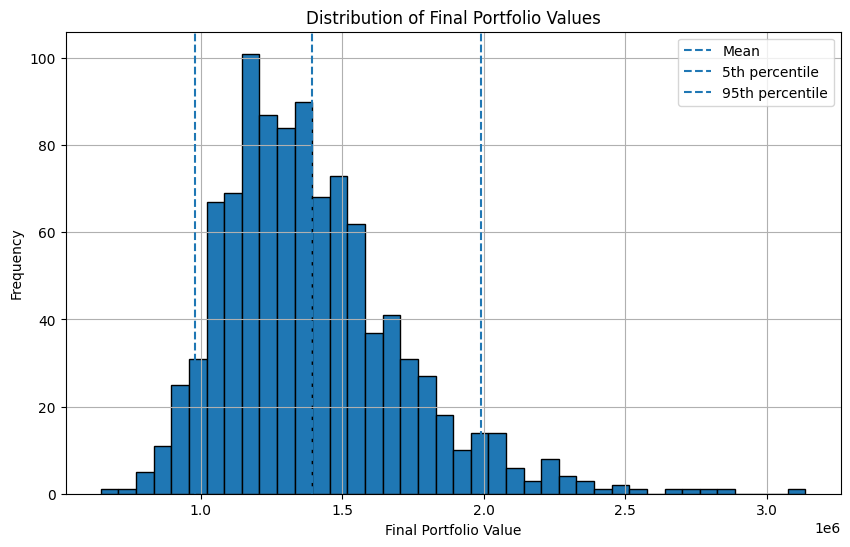

Initial portfolio value: 1000000
Mean final value: 1393689.064440509
5th percentile: 978726.7411525415
95th percentile: 1990927.543164328


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(final_portfolio_values, bins=40, edgecolor='black')
plt.axvline(final_portfolio_values.mean(), linestyle='--', label='Mean')
plt.axvline(np.percentile(final_portfolio_values, 5), linestyle='--', label='5th percentile')
plt.axvline(np.percentile(final_portfolio_values, 95), linestyle='--', label='95th percentile')
plt.title("Distribution of Final Portfolio Values")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

print("Initial portfolio value:", initial_portfolio_value)
print("Mean final value:", final_portfolio_values.mean())
print("5th percentile:", np.percentile(final_portfolio_values, 5))
print("95th percentile:", np.percentile(final_portfolio_values, 95))

In [ ]:
import plotly.graph_objects as go
sp500 = yf.download("^GSPC", start="2020-01-01", end="2026-01-01")['Close']
sp500 = sp500.dropna()
# If sp500 is a DataFrame, 'yf.download(...)'['Close'] will return a DataFrame with the column name as the ticker.
# So, rename the column '^GSPC' to 'SP500'.
sp500 = sp500.rename(columns={'^GSPC': 'SP500'})
combined = price_data.join(sp500, how="inner")
portfolio_prices = combined[tickers]
sp500_prices = combined["SP500"]
normalized_stocks = portfolio_prices / portfolio_prices.iloc[0]
portfolio_index = (normalized_stocks * weights).sum(axis=1)
portfolio_value = portfolio_index * initial_portfolio_value
sp500_value = (sp500_prices / sp500_prices.iloc[0])*initial_portfolio_value

fig = go.Figure()

fig.add_trace(go.Scatter(
 x=portfolio_value.index,
 y=portfolio_value,
 mode='lines',
 name='My Portfoio'
 ))
fig.add_trace(go.Scatter(
 x=sp500_value.index,
 y=sp500_value,
 mode='lines',
 name='S&p 500'
 ))
fig.update_layout(
    title='Portfolio vs S&P 500',
    xaxis_title='Date',
    yaxis_title='Portfolio Value ($)',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

/tmp/ipykernel_4033/1421645849.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
